In [6]:
from pathlib import Path
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import pyslammer as slam
from cycler import cycler

%matplotlib inline

plt.style.use(slam.psfigstyle)

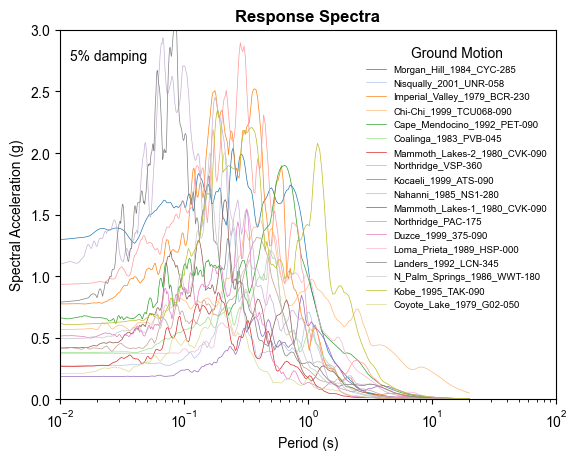

In [7]:
# Navigate to ground motion suite response spectra files
current_dir = os.getcwd()
folder_path = Path(current_dir).resolve().parents[0] / "technical" / "pySLAMMER_suite_resp"
csv_files = list(folder_path.glob("*.csv"))

# Read each CSV file into a DataFrame and store them in a list
freq_index = 0
resp_index = 1
spectra = {}
for csv_file in csv_files:
    data = np.loadtxt(csv_file, delimiter=",", skiprows=2)
    # convert response from cm/s^2 to g's
    data[:, resp_index] = data[:, resp_index] / 981
    spectra[csv_file.name.strip(".csv")] = data

# Scale by PGA:
target_pga = 0.5


# Initialize the plot
fig, ax = plt.subplots()
ax.set_prop_cycle(cycler(color=plt.cm.tab20.colors))
for motion in spectra:
    ax.plot(
        1 / spectra[motion][:, freq_index],
        spectra[motion][:, resp_index],
        label=motion,
        linewidth=0.5,
    )

ax.text(0.012, 2.75, "5% damping")
# Add labels, legend, and grid
ax.set_xlabel("Period (s)")
ax.set_ylabel("Spectral Acceleration (g)")
ax.set_title("Response Spectra")
ax.set_xscale("log")
ax.set_ylim(0, 3)
ax.set_xlim(0.01, 100)

ax.legend(
    loc="center left",
    bbox_to_anchor=(0.6, 0.6),
    fontsize="x-small",
    title="Ground Motion",
    title_fontsize="medium",
    frameon=False,
)

plt.show()


In [8]:
plt.savefig("resp_spectra.pdf", dpi=600, bbox_inches="tight")


<Figure size 640x480 with 0 Axes>

In [9]:
record_names = [
    # "Morgan_Hill_1984_CYC-285",
    "Nisqually_2001_UNR-058",
    "Imperial_Valley_1979_BCR-230",
    "Northridge_1994_PAC-175",
    # "Chi-Chi_1999_TCU068-090",
    "Cape_Mendocino_1992_PET-090",
    "Coalinga_1983_PVB-045",
    "Mammoth_Lakes-2_1980_CVK-090",
    # "Kocaeli_1999_ATS-090",
    "Nahanni_1985_NS1-280",
    "Mammoth_Lakes-1_1980_CVK-090",
    "Duzce_1999_375-090",
    "Loma_Prieta_1989_HSP-000",
    # "Landers_1992_LCN-345",
    # "N_Palm_Springs_1986_WWT-180",
    # "Kobe_1995_TAK-090",
    "Coyote_Lake_1979_G02-050",
    "Northridge_1994_VSP-360",
]


In [10]:
# Scale by PGA:
target_pga = 0.5

norm_spectra = {}
for record, data in spectra.items():
    if record in record_names:
        pga = data[-1, 1]
        norm_data = target_pga * data[:,1] / pga
        norm_spectra[record] = norm_data


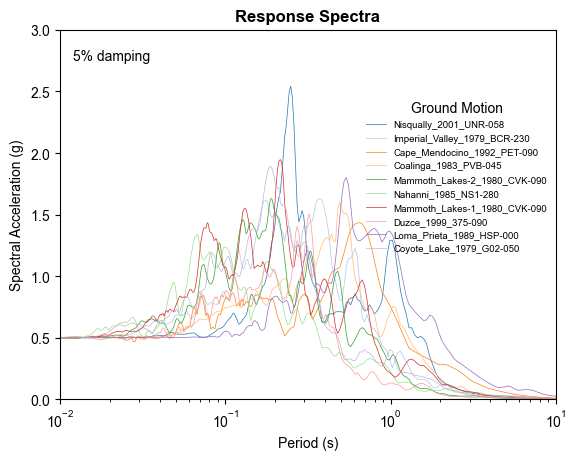

In [11]:
# # Navigate to ground motion suite response spectra files
# current_dir = os.getcwd()
# folder_path = (
#     Path(current_dir).resolve().parents[0] / "technical" / "pySLAMMER_suite_resp"
# )
# csv_files = list(folder_path.glob("*.csv"))

# # Read each CSV file into a DataFrame and store them in a list
# freq_index = 0
# resp_index = 1
# spectra = {}
# for csv_file in csv_files:
#     data = np.loadtxt(csv_file, delimiter=",", skiprows=2)
#     # convert response from cm/s^2 to g's
#     data[:, resp_index] = data[:, resp_index] / 981
#     spectra[csv_file.name.strip(".csv")] = data




# Initialize the plot
fig, ax = plt.subplots()
ax.set_prop_cycle(cycler(color=plt.cm.tab20.colors))
for motion in norm_spectra:
    ax.plot(
        1 / spectra[motion][:, freq_index],
        norm_spectra[motion][:],
        label=motion,
        linewidth=0.5,
    )

ax.text(0.012, 2.75, "5% damping")
# Add labels, legend, and grid
ax.set_xlabel("Period (s)")
ax.set_ylabel("Spectral Acceleration (g)")
ax.set_title("Response Spectra")
ax.set_xscale("log")
ax.set_ylim(0, 3)
ax.set_xlim(0.01, 10)

ax.legend(
    loc="center left",
    bbox_to_anchor=(0.6, 0.6),
    fontsize="x-small",
    title="Ground Motion",
    title_fontsize="medium",
    frameon=False,
)

# plt.show()
# plt.savefig("norm_resp_spectra.pdf", dpi=600, bbox_inches="tight")


In [30]:
record

'Coyote_Lake_1979_G02-050'

In [1]:
l = [1, 2, 3]

In [2]:
max(l)

3